In [128]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [129]:
zip_path = "/content/Plant_Disease_Workshop (1).zip"

extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
  zip_ref.extractall(extract_path)

  print("Dataset extracted successfully")

Dataset extracted successfully


In [101]:
print(os.listdir("/content"))

['.config', 'Plant_Disease_Workshop', 'Plant_Disease_Workshop (1).zip', 'sample_data']


In [102]:
dataset_path = "/content/Plant_Disease_Workshop"
print(os.listdir(dataset_path))

['val', 'train']


In [103]:
dataset_path = "/content/Plant_Disease_Workshop/train"
print(os.listdir(dataset_path))

['Potato___Late_blight', 'Potato___Early_blight', 'Potato___healthy']


In [104]:
dataset_path = "/content/Plant_Disease_Workshop/val"
print(os.listdir(dataset_path))

['Potato___Late_blight', 'Potato___Early_blight', 'Potato___healthy']


In [105]:
train_path = "/content/Plant_Disease_Workshop/train"
val_path = "/content/Plant_Disease_Workshop/val"

print("==========TRAIN DATA==========")

for folder in os.listdir(train_path):
  folder_path = os.path.join(train_path, folder)
  print(folder, ":", len(os.listdir(folder_path)), "images")

  print("\n==========VALIDATION DATA==========\n")

for folder in os.listdir(val_path):
  folder_path = os.path.join(val_path, folder)
  print(folder, ":", len(os.listdir(folder_path)), "images")

==========TRAIN DATA==========
Potato___Late_blight : 800 images

==========VALIDATION DATA==========

Potato___Early_blight : 800 images

==========VALIDATION DATA==========

Potato___healthy : 121 images

==========VALIDATION DATA==========

Potato___Late_blight : 200 images
Potato___Early_blight : 200 images
Potato___healthy : 31 images


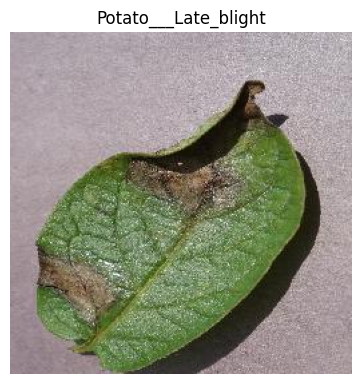

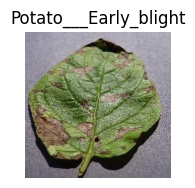

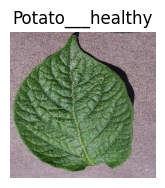

In [106]:
plt.figure(figsize=(15,5))
classes = os.listdir(train_path)
for i, folder in enumerate(classes):
     image_name = os.listdir(os.path.join(train_path, folder))[0]
     image_path = os.path.join(train_path, folder, image_name)
     image = cv2.imread(image_path)
     image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
     plt.subplot(1,3, i+1)
     plt.imshow(image)
     plt.title(folder)
     plt.axis("off")
     plt.show()

In [107]:
train_path = "/content/Plant_Disease_Workshop/train"
val_path = "/content/Plant_Disease_Workshop/val"
image_size = (64,64)

In [108]:
X_train = []
y_train = []

X_val = []
y_val = []



In [109]:
for label in os.listdir(train_path):
  folder_path = os.path.join(train_path, label)
  for image_name in os.listdir(folder_path):
    image_path = os.path.join(folder_path, image_name)
    image = cv2.imread(image_path)
    image = cv2.resize(image, image_size)
    X_train.append(image)
    y_train.append(label)
print("Training Image Loaded Successfully")

Training Image Loaded Successfully


In [110]:
for label in os.listdir(val_path):
  folder_path = os.path.join(val_path, label)
  for image_name in os.listdir(folder_path):
    image_path = os.path.join(folder_path, image_name)
    image = cv2.imread(image_path)
    image = cv2.resize(image, image_size)
    X_val.append(image)
    y_val.append(label)
print("Validation Image Loaded Successfully")

Validation Image Loaded Successfully


In [111]:
print("Training Images :", len(X_train))
print("Training Labels :", len(y_train))
print()

print("Validation Images :", len(X_val))
print("Validation Labels :", len(y_val))

Training Images : 1721
Training Labels : 1721

Validation Images : 431
Validation Labels : 431


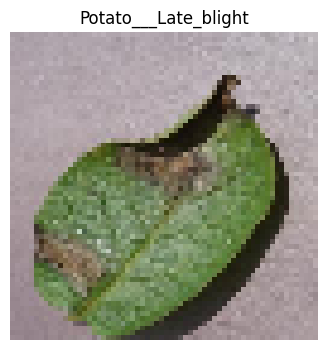

In [112]:
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(X_train[0], cv2.COLOR_BGR2RGB))
plt.title(y_train[0])
plt.axis("off")
plt.show()

In [113]:
X_train = np.array(X_train)
X_val = np.array(X_val)

y_train = np.array(y_train)
y_val = np.array(y_val)

print("Converted Successfully!")

Converted Successfully!


In [114]:
print("Training Shape :",X_train.shape)
print("Validation Shape :",X_val.shape)

Training Shape : (1721, 64, 64, 3)
Validation Shape : (431, 64, 64, 3)


In [115]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)

print("Images Flattened Successfully!")

Images Flattened Successfully!


In [116]:
print("Training Shape :",X_train.shape)
print("Validation Shape :",X_val.shape)

Training Shape : (1721, 12288)
Validation Shape : (431, 12288)


In [117]:
X_train = X_train / 255.0
X_val = X_val/ 255.0

print("Normalization Completed!")

Normalization Completed!


In [118]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_val = encoder.transform(y_val)

print("Label Encoded Successfully!")

Label Encoded Successfully!


In [119]:
print("Encoded Classes:")
print(encoder.classes_)

print()

print("First 10 Labels:")
print(y_train[:10])

Encoded Classes:
['Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy']

First 10 Labels:
[1 1 1 1 1 1 1 1 1 1]


In [120]:
print("Training Features Shape :",X_train.shape)
print("Training Labels Shape :",X_train.shape)

print()
print("Validation Features Shape :",X_val.shape)
print("Validation Labels Shape :",y_val.shape)

Training Features Shape : (1721, 12288)
Training Labels Shape : (1721, 12288)

Validation Features Shape : (431, 12288)
Validation Labels Shape : (431,)


In [121]:
logistic_model = LogisticRegression(max_iter=1000)

print("Logistic Regression Model Created Successfully!")

Logistic Regression Model Created Successfully!


In [125]:
logistic_model.fit(X_train,y_train)
print("Model training completed")

Model training completed


In [126]:
y_pred = logistic_model.predict(X_val)
print("Prediction Completed")

Prediction Completed


In [127]:
print("Actual Labels :",y_val[:10])
print("Predicted Labels :",y_pred[:10])

Actual Labels : [1 1 1 1 1 1 1 1 1 1]
Predicted Labels : [1 1 1 1 1 1 1 1 1 1]


In [132]:
acc = accuracy_score(y_val, y_pred)
print("Accuracy Score is :",round(acc * 100, 2),"%")

Accuracy Score is : 90.95 %


In [133]:
cmx = confusion_matrix(y_val, y_pred)
print(cmx)

[[186  14   0]
 [  8 189   3]
 [  0  14  17]]


In [134]:
print(classification_report(y_val, y_pred, target_names=encoder.classes_))

                       precision    recall  f1-score   support

Potato___Early_blight       0.96      0.93      0.94       200
 Potato___Late_blight       0.87      0.94      0.91       200
     Potato___healthy       0.85      0.55      0.67        31

             accuracy                           0.91       431
            macro avg       0.89      0.81      0.84       431
         weighted avg       0.91      0.91      0.91       431



In [136]:
predicted_labels = encoder.inverse_transform(y_pred[:10])

print("First 10 Predicted Disease Names:")
print(predicted_labels)

First 10 Predicted Disease Names:
['Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight']


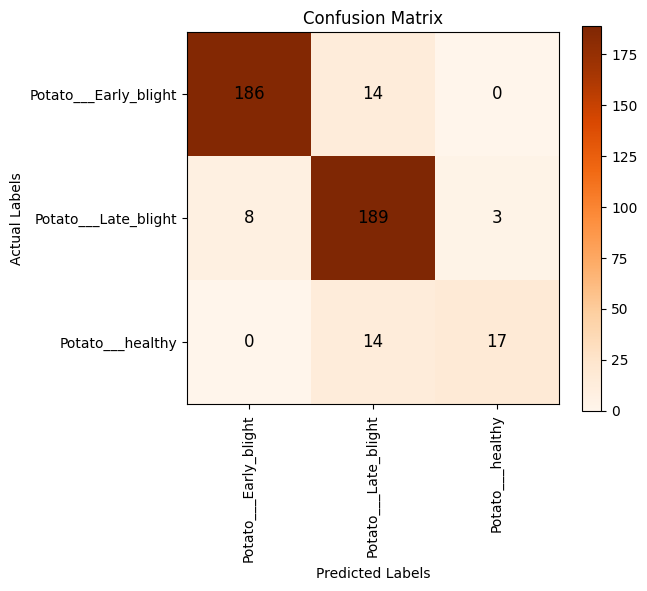

In [139]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.imshow(cmx, cmap="Oranges")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(3), encoder.classes_, rotation=90)
plt.yticks(range(3), encoder.classes_)

for i in range(len(cmx)):
  for j in range(len(cmx)):
    plt.text(j, i, cmx[i][j],
             ha="center",
             va="center",
             color="black",
             fontsize=12)
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

In [141]:
print("="*40)
print("Logistic Regression Completed Successfully")
print("="*40)

print(f"Accuracy : {acc*100:.2f}%")

Logistic Regression Completed Successfully
Accuracy : 90.95%


In [143]:
svm_model = SVC(kernel="linear")

print("Support Vector Machine Model Created Successfully!")

Support Vector Machine Model Created Successfully!


In [144]:
svm_model.fit(X_train,y_train)
print("Model Trainning Completed")



Model Trainning Completed


In [145]:
svm_pred=svm_model.predict(X_val)
print("Prediction Completed")


Prediction Completed


In [146]:
svm_acc = accuracy_score(y_val,svm_pred)
print("Accuracy:",round(svm_acc * 100,2),"%")

Accuracy: 91.18 %


In [152]:
svm_cm = confusion_matrix(y_val, svm_pred)
print("Confusion Matrix:",cmx)


Confusion Matrix: [[183  17   0]
 [  9 188   3]
 [  1   8  22]]


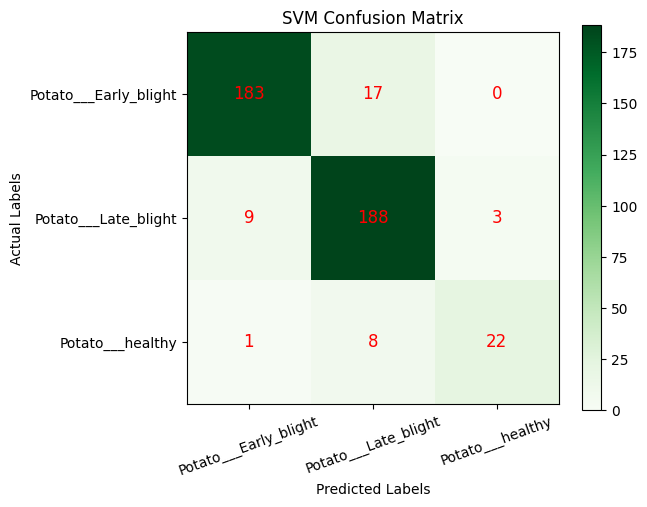

In [153]:
plt.figure(figsize=(6,5))
plt.imshow(svm_cm, cmap="Greens")
plt.title("SVM Confusion Matrix")
plt.colorbar()

plt.xticks(range(3), encoder.classes_, rotation=20)
plt.yticks(range(3), encoder.classes_)

for i in range(len(svm_cm)):
  for j in range(len(svm_cm)):
    plt.text(j, i, svm_cm[i][j],
             ha="center",
             va="center",
             color="red",
             fontsize=12)
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

In [157]:
print("="*40)
print("SVM Completed Successfully")
print("="*40)

print(f"Accuracy :",round(svm_acc*100,2),"%")

SVM Completed Successfully
Accuracy : 91.18 %


In [167]:
from google.colab import files

uploaded = files.upload()

Saving pngtree-green-leaf-for-element-png-image_14904901.png to pngtree-green-leaf-for-element-png-image_14904901.png


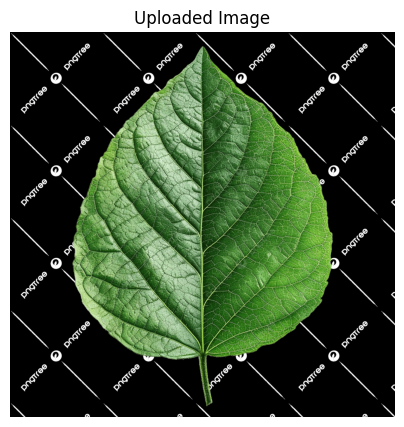

In [168]:
image_name = list(uploaded.keys())[0]
image_path = cv2.imread(image_name)
image_rgb = cv2.cvtColor(image_path, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5,5))
plt.imshow(image_rgb)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()


In [169]:
test_image = cv2.resize(image, (64, 64))
test_image = test_image.reshape(1, -1)
test_image = test_image / 255.0
print("Image Preprocessed Successfully!")

Image Preprocessed Successfully!


In [170]:
prediction = svm_model.predict(test_image)
predicted_label = encoder.inverse_transform(prediction)
print("Predicted Disease Name:", predicted_label[0])

Predicted Disease Name: Potato___healthy


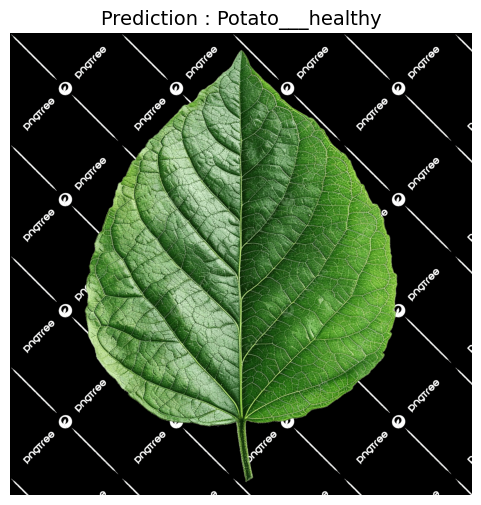

In [174]:
plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.title("Prediction : "+predicted_label[0], fontsize=14)
plt.axis("off")
plt.show()


In [177]:
if predicted_label[0] == "Potato___Early_blight":
  print("Disease: Early Blight")
  print("Advice: Remove inflected leaves and apply fungicides")
elif predicted_label[0] == "Potato___Late_blight":
  print("Disease: Late Blight")
  print("Advice: Improve drainage, avoid overhead watering, and use recommended fungicides")
elif predicted_label[0] == "Potato___healthy":
  print("Disease: Healthy Leaf")
  print("Advice: No disease detected. Continue regular crop care")

Disease: Healthy Leaf
Advice: No disease detected. Continue regular crop care


In [180]:
comparison = {
    "Model": ["Logistic Regression", "Support Vector Machine"],
    "Accuracy": [acc * 100, svm_acc * 100]
}

import pandas as pd
comparison_df = pd.DataFrame(comparison)
comparison_df

,Model,Accuracy
0,Logistic Regression,90.951276
1,Support Vector Machine,91.183295


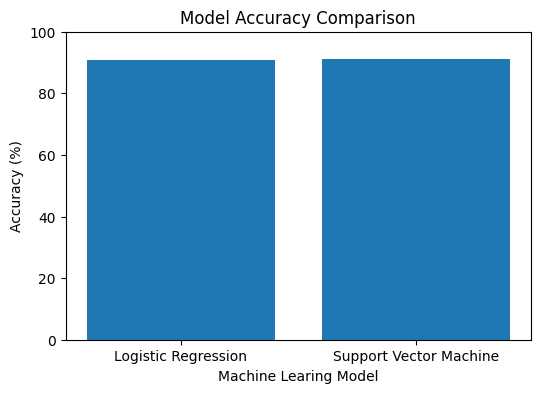

In [182]:
plt.figure(figsize=(6,4))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learing Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.show()

In [184]:
if svm_acc > acc:
  print("Best Model: Support Vector Machine (SVM)")
else:
  print("Best Model: Logistic Regression")

Best Model: Support Vector Machine (SVM)
